# CSC 5800 - Intelligent Systems: Algorithms and Tools
## Project: Hybrid Network Intrusion Detection System
### Notebook 2: Data Preprocessing & Exploratory Data Analysis
**Student:** Fahad Qaseem Khawar  
**Instructor:** Dr. Suzan Arslanturk  
**Semester:** Winter 2026

---
This notebook covers:
- Loading and inspecting the raw dataset
- Data cleaning: missing values, duplicates, whitespace in labels
- Feature engineering and type correction
- Exploratory Data Analysis with visualizations
- Feature selection using mutual information
- Encoding, normalization, and train/test split
- Saving processed data to Drive for Notebook 3

## 0. Mount Drive & Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

BASE   = '/content/drive/MyDrive/CSC5800_NIDS_Project'
RAW    = f'{BASE}/data/raw'
PROC   = f'{BASE}/data/processed'
FIGS   = f'{BASE}/figures'

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = 'viridis'
print('Environment ready.')

Mounted at /content/drive
Environment ready.


## 1. Load Dataset
We use the official training and testing CSVs from UNSW-NB15.  
These provide a standardized split used in published research.

In [2]:
col_names = [
    'srcip','sport','dstip','dsport','proto','state','dur','sbytes',
    'dbytes','sttl','dttl','sloss','dloss','service','Sload','Dload',
    'Spkts','Dpkts','swin','dwin','stcpb','dtcpb','smeansz','dmeansz',
    'trans_depth','res_bdy_len','Sjit','Djit','Stime','Ltime','Sintpkt',
    'Dintpkt','tcprtt','synack','ackdat','is_sm_ips_ports','ct_state_ttl',
    'ct_flw_http_mthd','is_ftp_login','ct_ftp_cmd','ct_srv_src','ct_srv_dst',
    'ct_dst_ltm','ct_src_ltm','ct_src_dport_ltm','ct_dst_sport_ltm',
    'ct_dst_src_ltm','attack_cat','label'
]

train_raw = pd.read_csv(f'{RAW}/UNSW_NB15_training-set.csv')
test_raw  = pd.read_csv(f'{RAW}/UNSW_NB15_testing-set.csv')

print(f'Training set : {train_raw.shape}')
print(f'Testing set  : {test_raw.shape}')
print(f'Columns      : {list(train_raw.columns)}')

Training set : (82332, 45)
Testing set  : (175341, 45)
Columns      : ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [3]:
df = pd.concat([train_raw, test_raw], ignore_index=True)
print(f'Combined shape: {df.shape}')
df.head(3)

Combined shape: (257673, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0


## 2. Initial Data Inspection

In [4]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Memory Usage ===')
print(f'{df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

=== Data Types ===
id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             i

In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing cells: {missing.sum()}')

=== Missing Values ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing cells: 0


In [6]:
print('=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes:,} ({dupes/len(df)*100:.2f}%)')

=== Duplicate Rows ===
Duplicate rows: 0 (0.00%)


In [7]:
print('=== Basic Statistics ===')
df.describe(include='all').T

=== Basic Statistics ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,257673.0,NaN,NaN,NaN,72811.823858,48929.917641,1.0,32210.0,64419.0,110923.0,175341.0
dur,257673.0,NaN,NaN,NaN,1.246715,5.974305,0.0,0.000008,0.004285,0.685777,59.999989
proto,257673,133,tcp,123041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,257673,13,-,141321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,257673,11,FIN,117164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spkts,257673.0,NaN,NaN,NaN,19.777144,135.947152,1.0,2.0,4.0,12.0,10646.0
dpkts,257673.0,NaN,NaN,NaN,18.514703,111.985965,0.0,0.0,2.0,10.0,11018.0
sbytes,257673.0,NaN,NaN,NaN,8572.951803,173773.880605,24.0,114.0,528.0,1362.0,14355774.0
dbytes,257673.0,NaN,NaN,NaN,14387.287543,146199.281939,0.0,0.0,178.0,1064.0,14657531.0
rate,257673.0,NaN,NaN,NaN,91253.91244,160344.636693,0.0,30.789277,2955.664893,125000.0003,1000000.003


## 3. Data Cleaning
### 3.1 Fix Label Whitespace (Known Dataset Issue)

In [8]:
print('Before cleaning - attack_cat unique values:')
print(df['attack_cat'].unique())

df['attack_cat'] = df['attack_cat'].astype(str).str.strip()
df['attack_cat'] = df['attack_cat'].replace({
    'Backdoors': 'Backdoor',
    'nan': 'Normal'
})

print('\nAfter cleaning - attack_cat unique values:')
print(sorted(df['attack_cat'].unique()))

Before cleaning - attack_cat unique values:
['Normal' 'Reconnaissance' 'Backdoor' 'DoS' 'Exploits' 'Analysis'
 'Fuzzers' 'Worms' 'Shellcode' 'Generic']

After cleaning - attack_cat unique values:
['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


### 3.2 Drop Non-Informative Columns

In [9]:
drop_cols = ['srcip', 'dstip', 'sport', 'dsport', 'Stime', 'Ltime', 'stcpb', 'dtcpb']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
print(f'Dropped columns: {drop_cols}')
print(f'Remaining shape: {df.shape}')

Dropped columns: ['srcip', 'dstip', 'sport', 'dsport', 'Stime', 'Ltime', 'stcpb', 'dtcpb']
Remaining shape: (257673, 43)


### 3.3 Handle Missing Values

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['attack_cat']]

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Missing values after imputation: {df.isnull().sum().sum()}')

Missing values after imputation: 0


### 3.4 Remove Duplicates

In [11]:
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows before: {before:,}  |  Rows after: {len(df):,}  |  Removed: {before - len(df):,}')

Rows before: 257,673  |  Rows after: 257,673  |  Removed: 0


### 3.5 Fix Numeric Columns Stored as Strings

In [12]:
for col in ['ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print('Dtype correction done.')
print(df[['ct_flw_http_mthd','is_ftp_login','ct_ftp_cmd']].dtypes)

Dtype correction done.
ct_flw_http_mthd    int64
is_ftp_login        int64
ct_ftp_cmd          int64
dtype: object


## 4. Exploratory Data Analysis
### 4.1 Class Distribution (Binary)

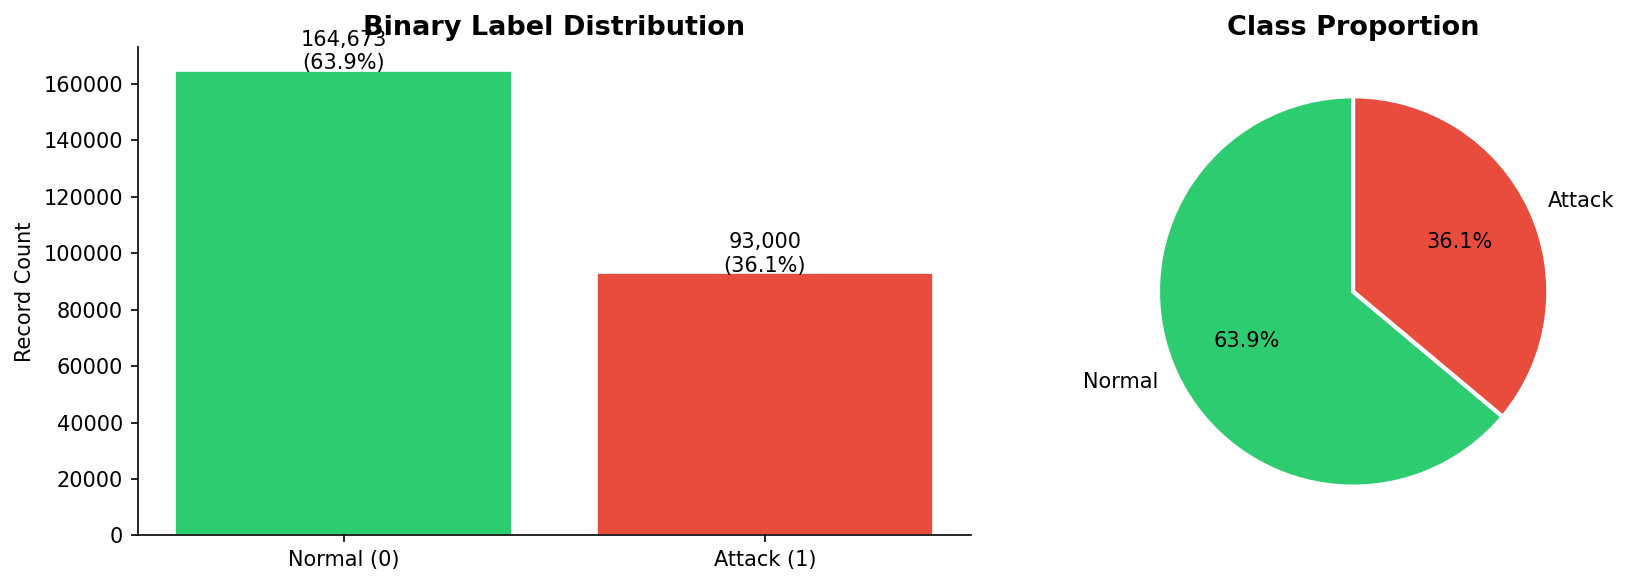

label
1    164673
0     93000
Name: count, dtype: int64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df['label'].value_counts()
axes[0].bar(['Normal (0)', 'Attack (1)'], label_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Binary Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Record Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(label_counts.values, labels=['Normal', 'Attack'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGS}/01_binary_class_dist.png', bbox_inches='tight')
plt.show()
print(label_counts)

### 4.2 Attack Category Distribution

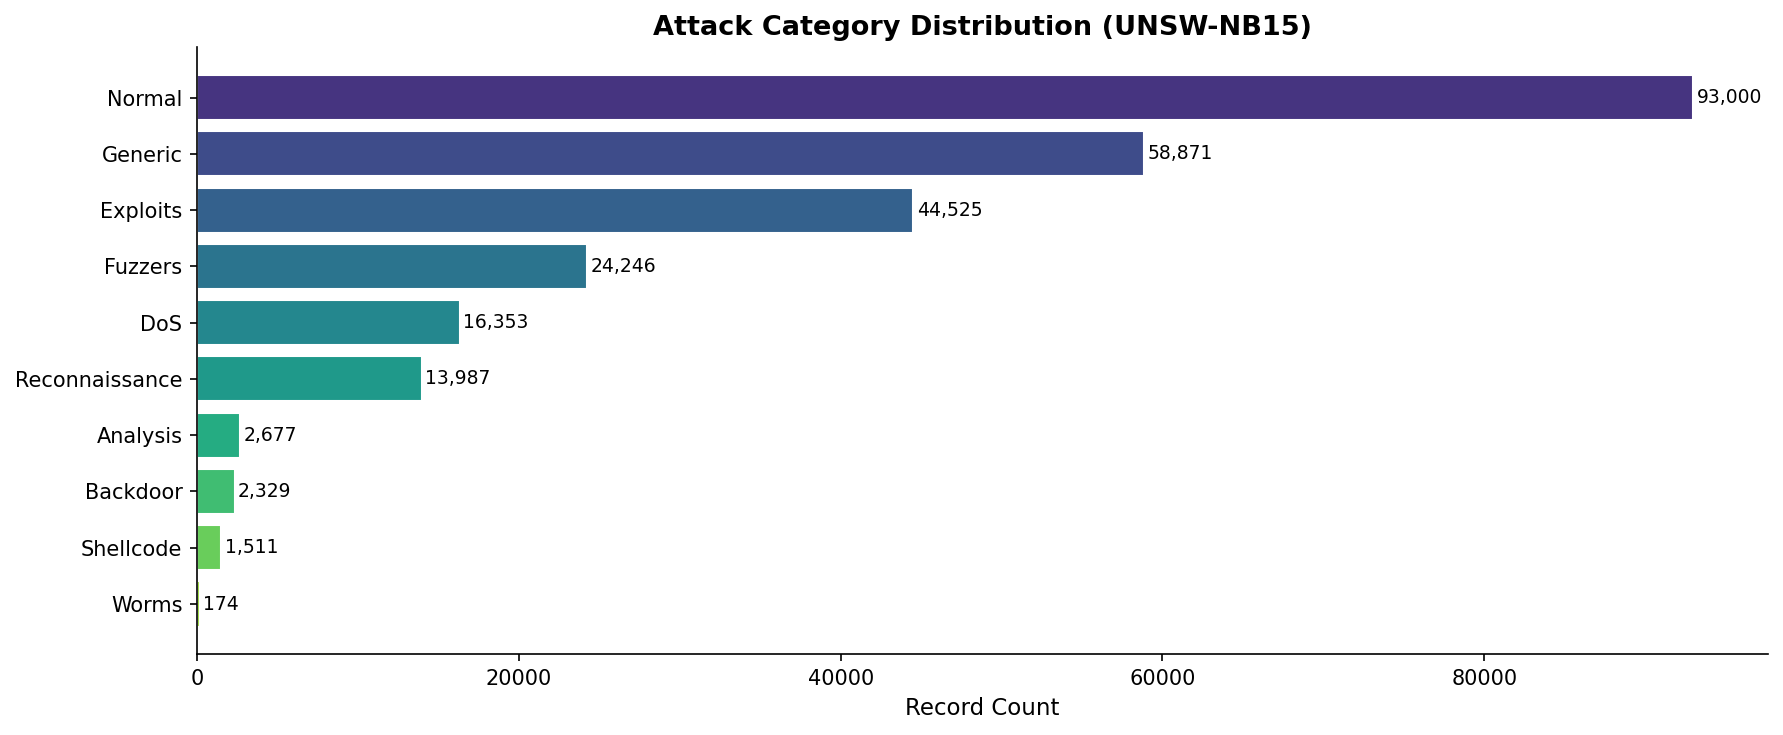

In [14]:
attack_counts = df['attack_cat'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(attack_counts)))
bars = ax.barh(attack_counts.index, attack_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, attack_counts.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Record Count', fontsize=11)
ax.set_title('Attack Category Distribution (UNSW-NB15)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIGS}/02_attack_cat_dist.png', bbox_inches='tight')
plt.show()

### 4.3 Feature Distributions - Key Numeric Features

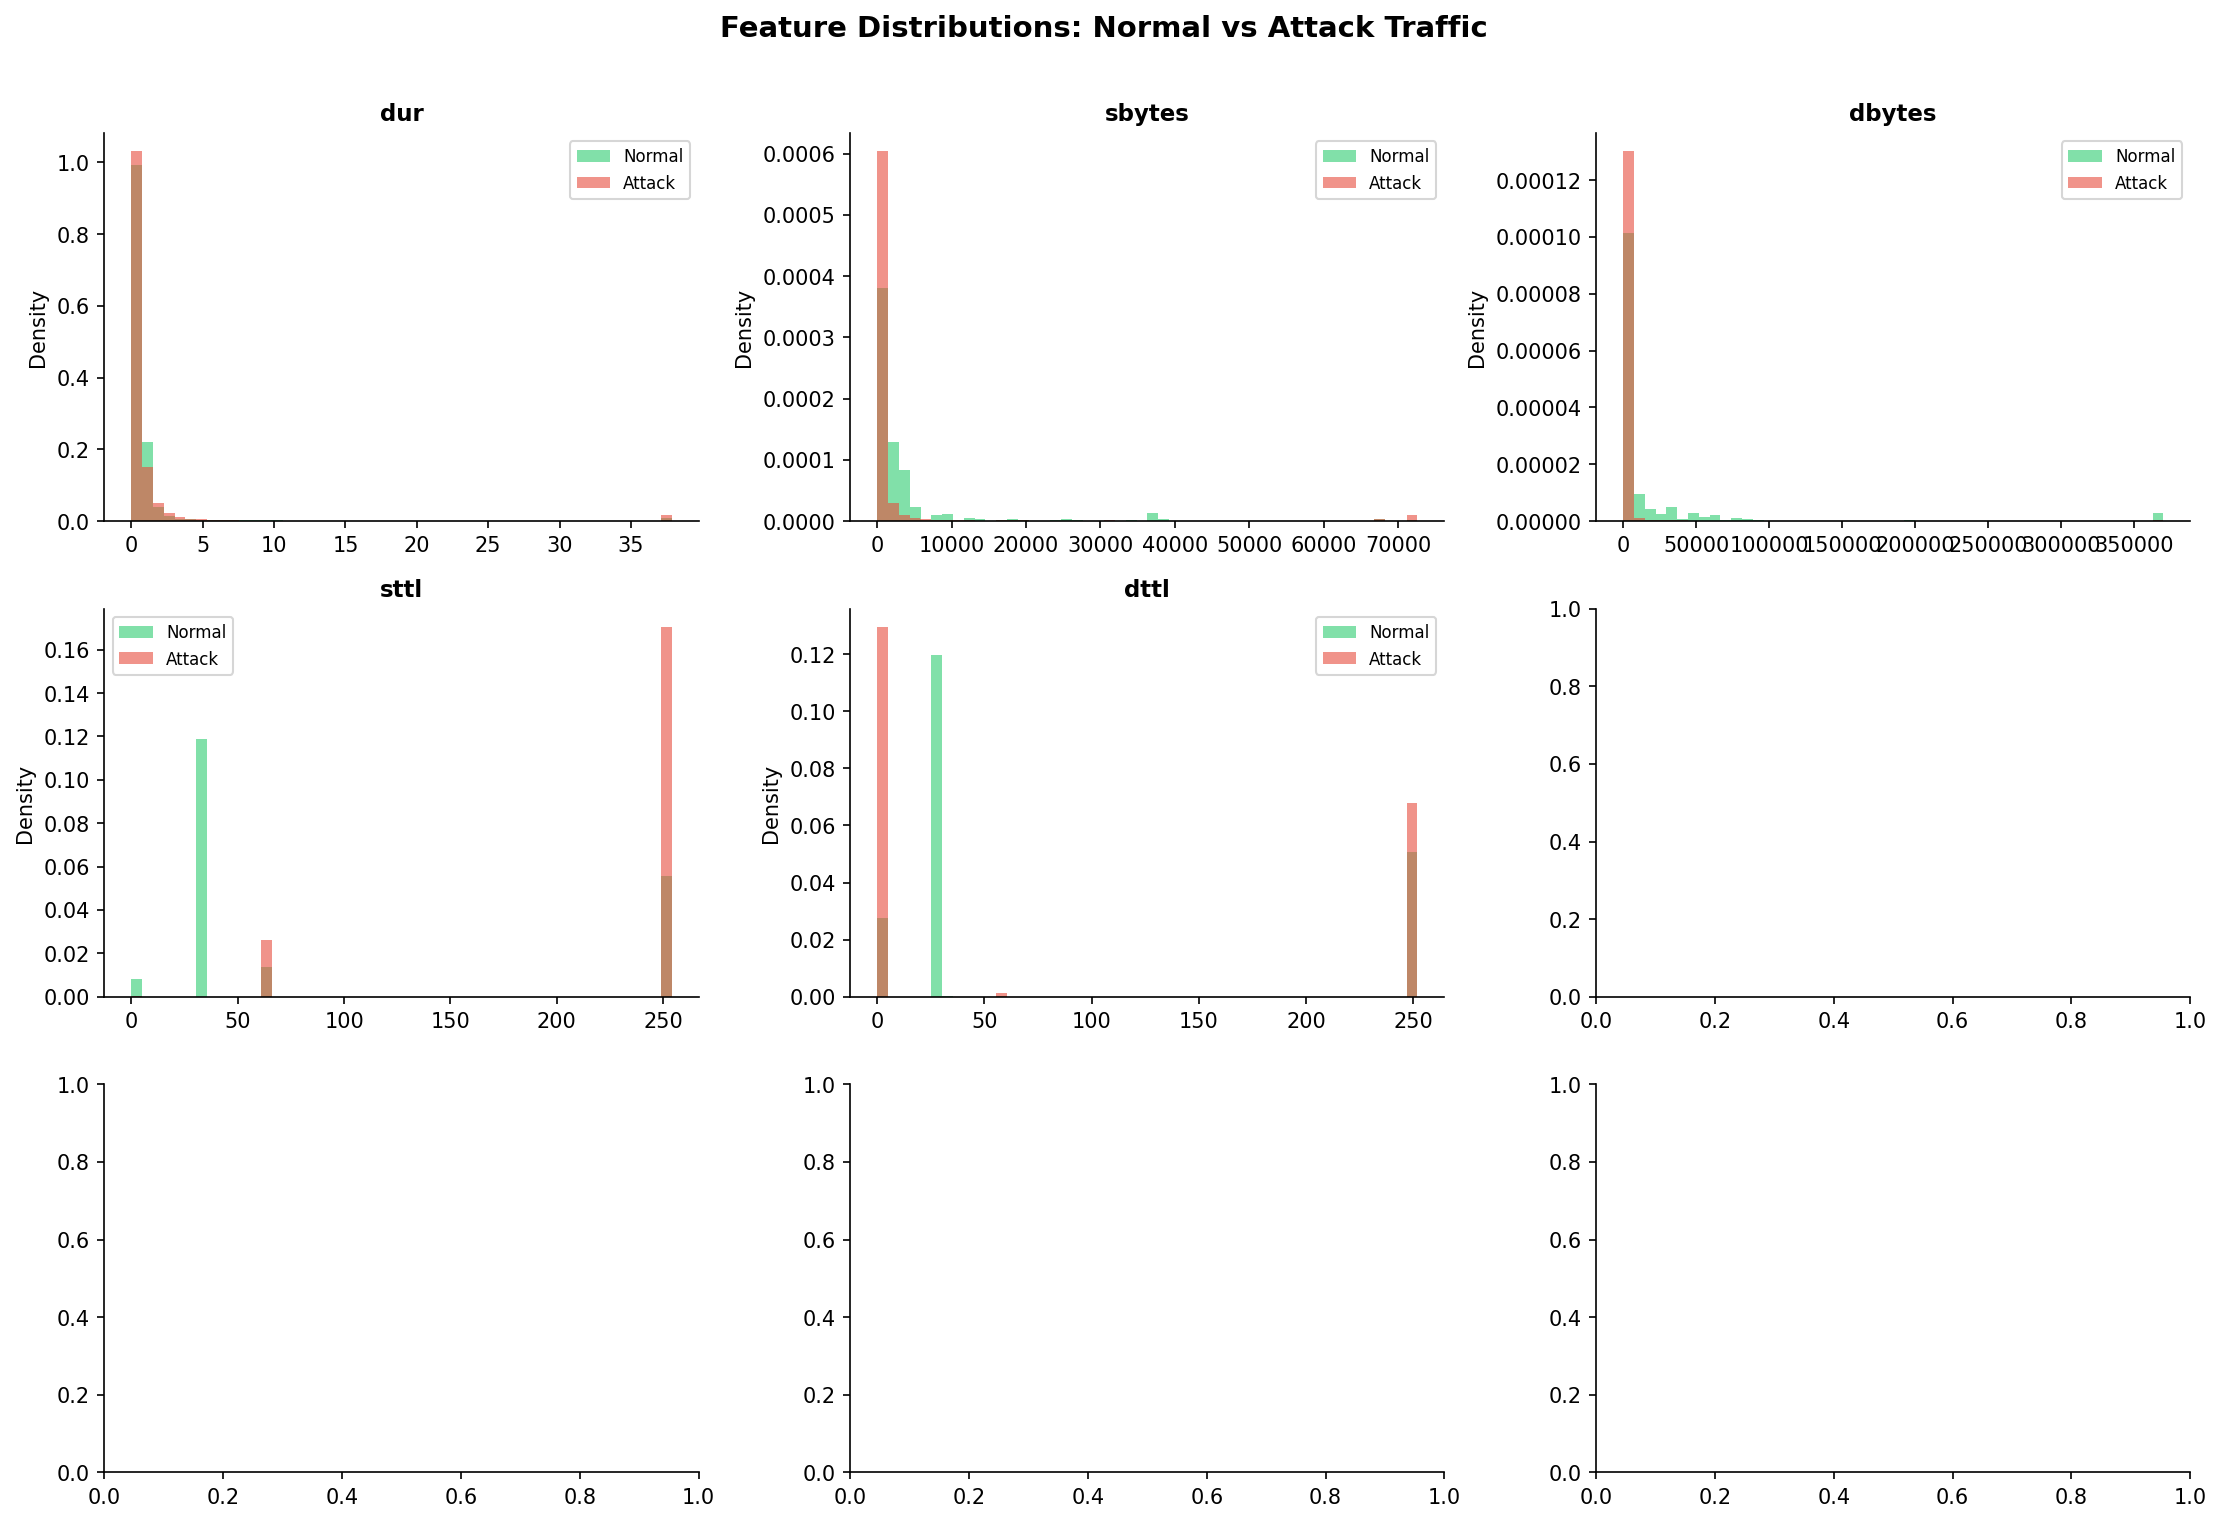

In [15]:
key_features = ['dur', 'sbytes', 'dbytes', 'Sload', 'Dload', 'Sjit', 'Djit', 'sttl', 'dttl']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    normal = df[df['label'] == 0][feat].clip(upper=df[feat].quantile(0.99))
    attack = df[df['label'] == 1][feat].clip(upper=df[feat].quantile(0.99))
    axes[i].hist(normal, bins=50, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    axes[i].hist(attack, bins=50, alpha=0.6, color='#e74c3c', label='Attack', density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Normal vs Attack Traffic', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGS}/03_feature_distributions.png', bbox_inches='tight')
plt.show()

### 4.4 Correlation Heatmap

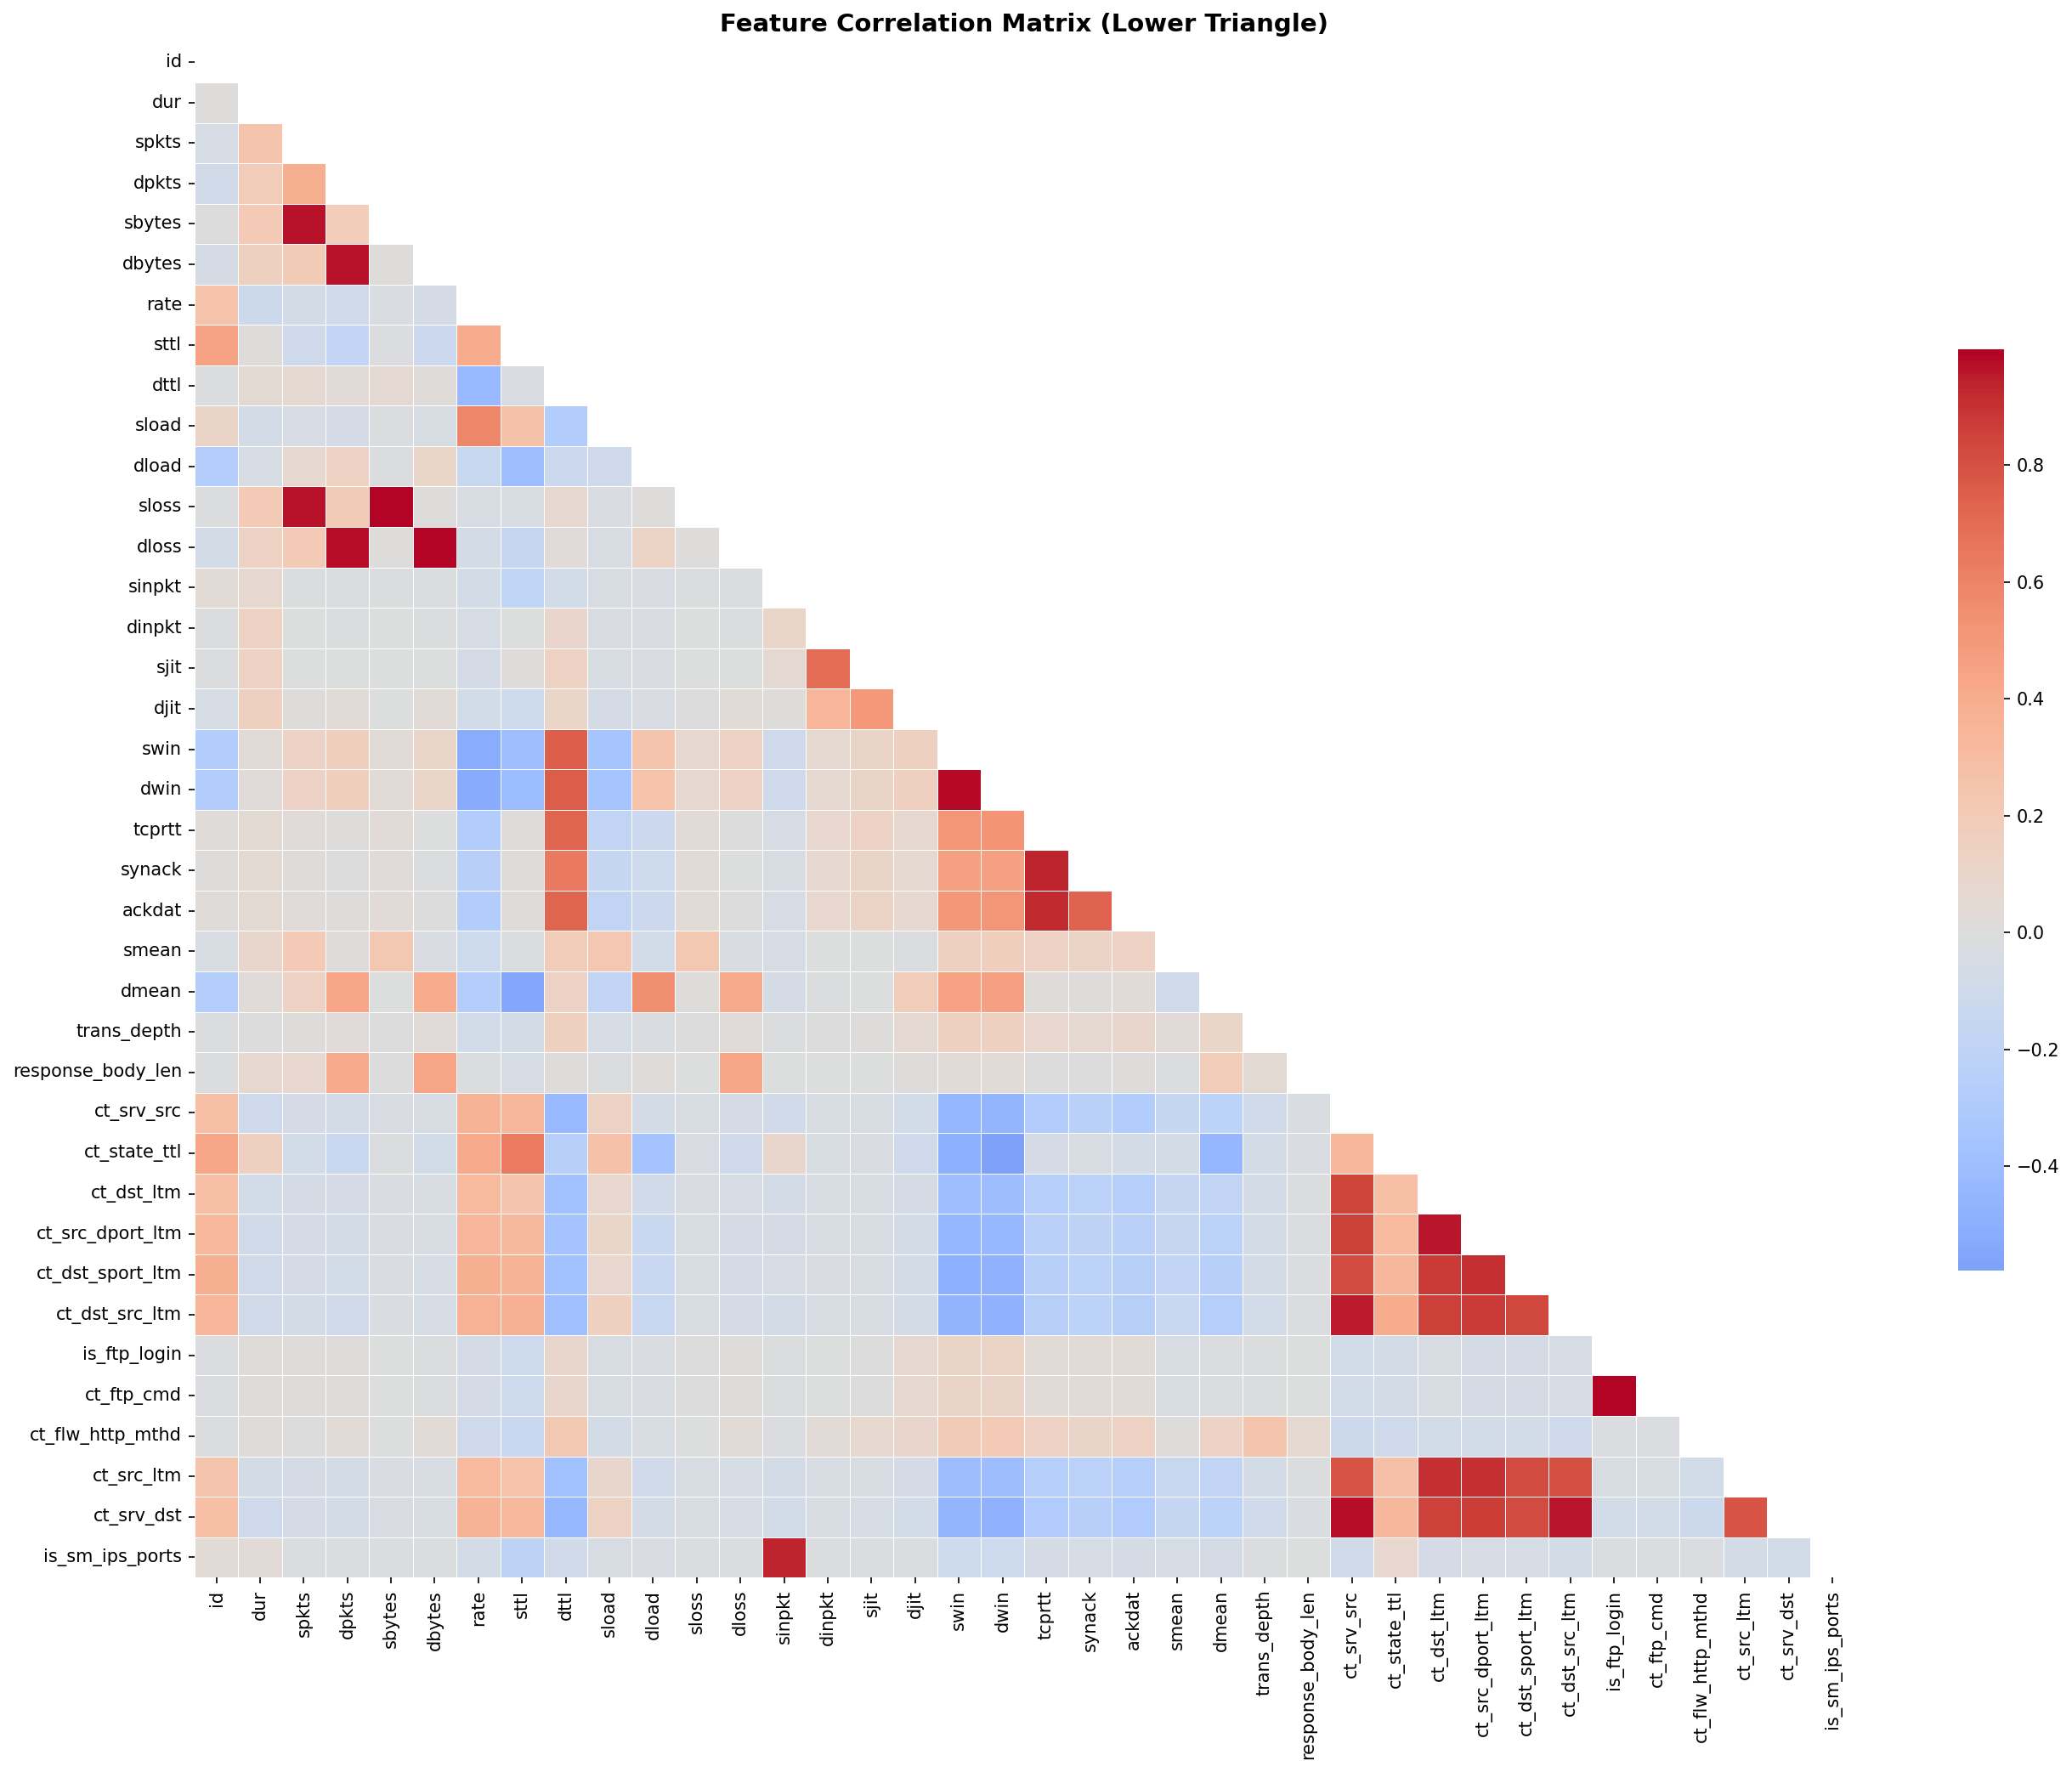

In [16]:
num_df = df.select_dtypes(include=[np.number]).drop(columns=['label'], errors='ignore')
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGS}/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 4.5 Protocol & Service Distribution

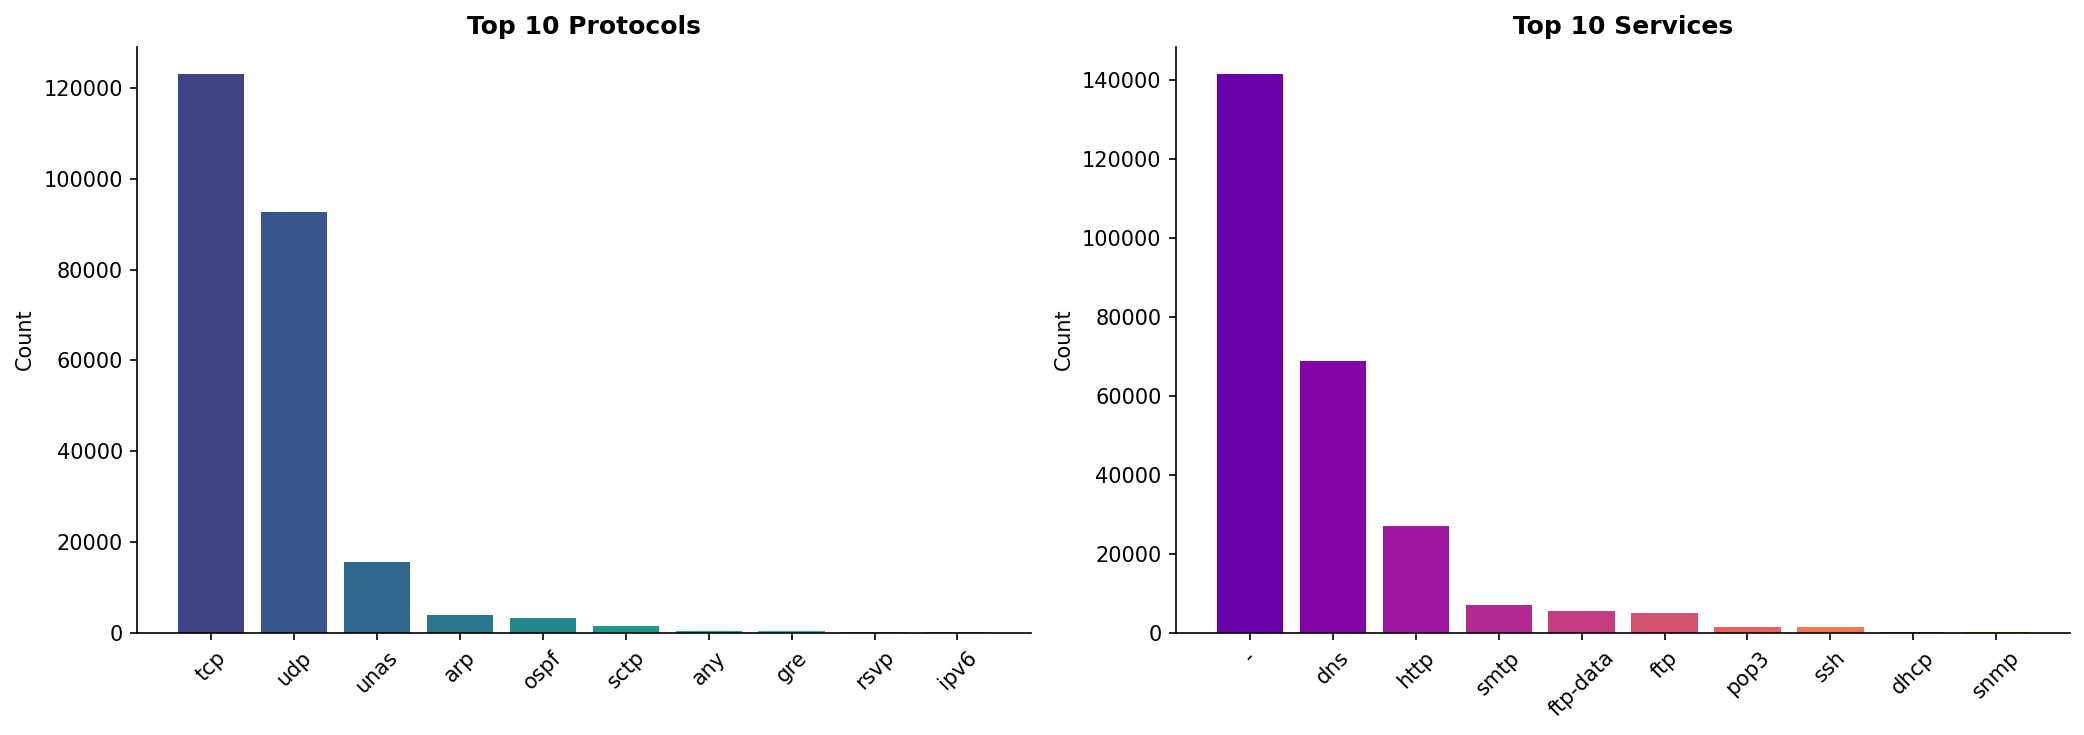

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

proto_counts = df['proto'].value_counts().head(10)
axes[0].bar(proto_counts.index, proto_counts.values,
            color=plt.cm.viridis(np.linspace(0.2, 0.8, len(proto_counts))))
axes[0].set_title('Top 10 Protocols', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

if 'service' in df.columns:
    svc_counts = df['service'].value_counts().head(10)
    axes[1].bar(svc_counts.index, svc_counts.values,
                color=plt.cm.plasma(np.linspace(0.2, 0.8, len(svc_counts))))
    axes[1].set_title('Top 10 Services', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{FIGS}/05_proto_service_dist.png', bbox_inches='tight')
plt.show()

### 4.6 Attack Type vs Protocol Heatmap

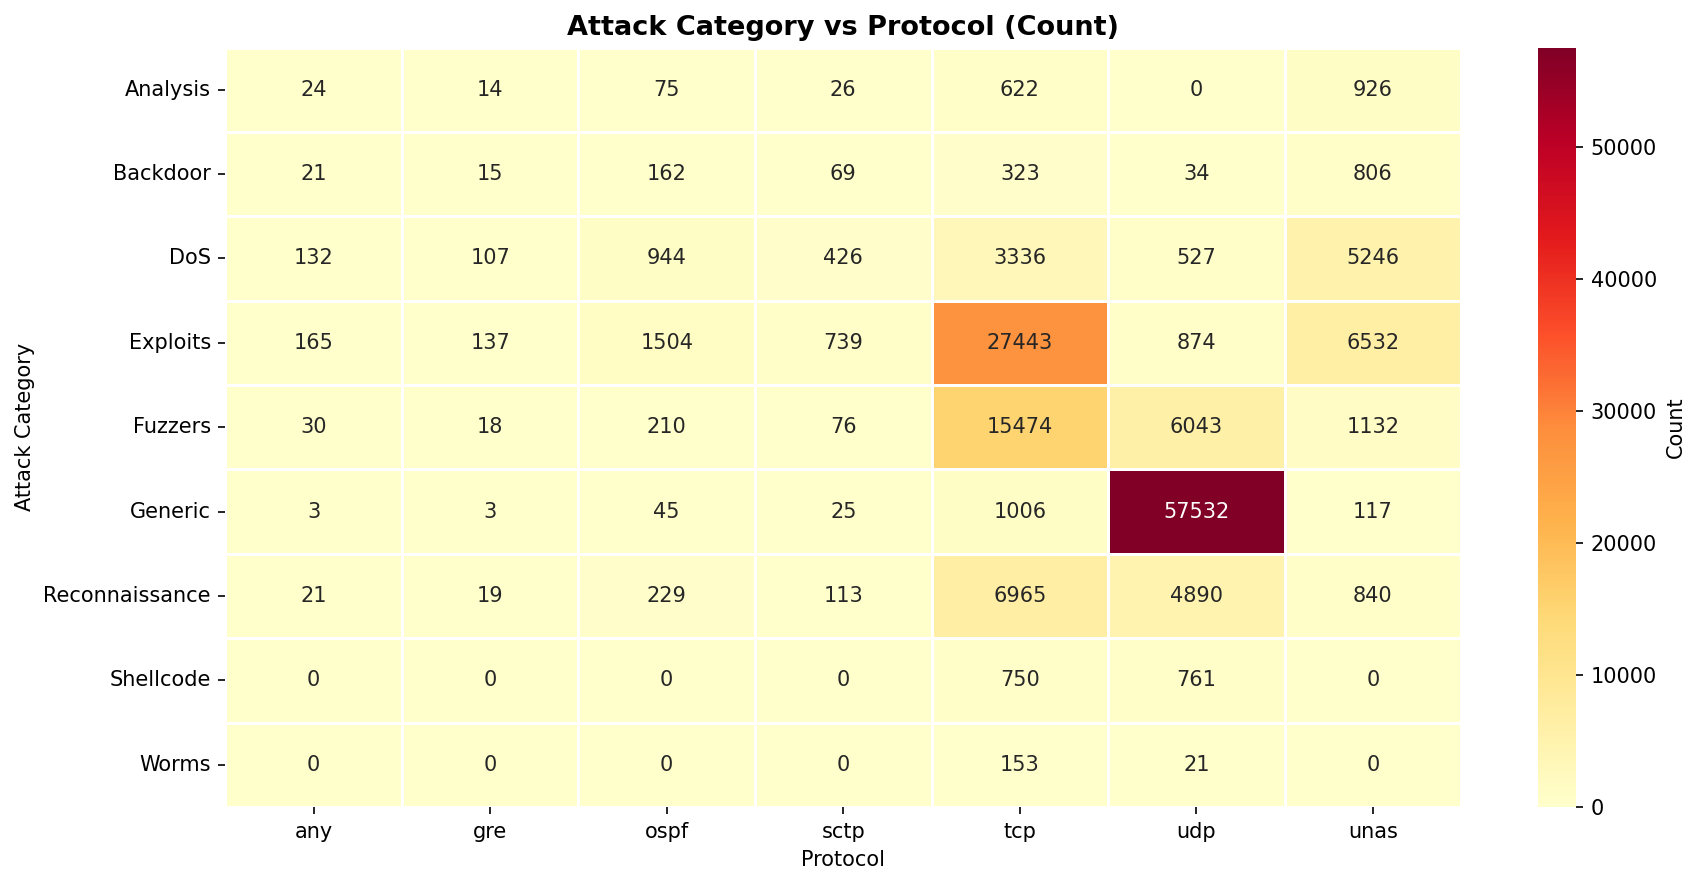

In [18]:
top_protos = df['proto'].value_counts().head(8).index
attack_only = df[df['label'] == 1]
pivot = attack_only[attack_only['proto'].isin(top_protos)].groupby(
    ['attack_cat', 'proto']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Attack Category vs Protocol (Count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Protocol')
ax.set_ylabel('Attack Category')
plt.tight_layout()
plt.savefig(f'{FIGS}/06_attack_proto_heatmap.png', bbox_inches='tight')
plt.show()

### 4.7 Boxplots - Key Features by Attack Category

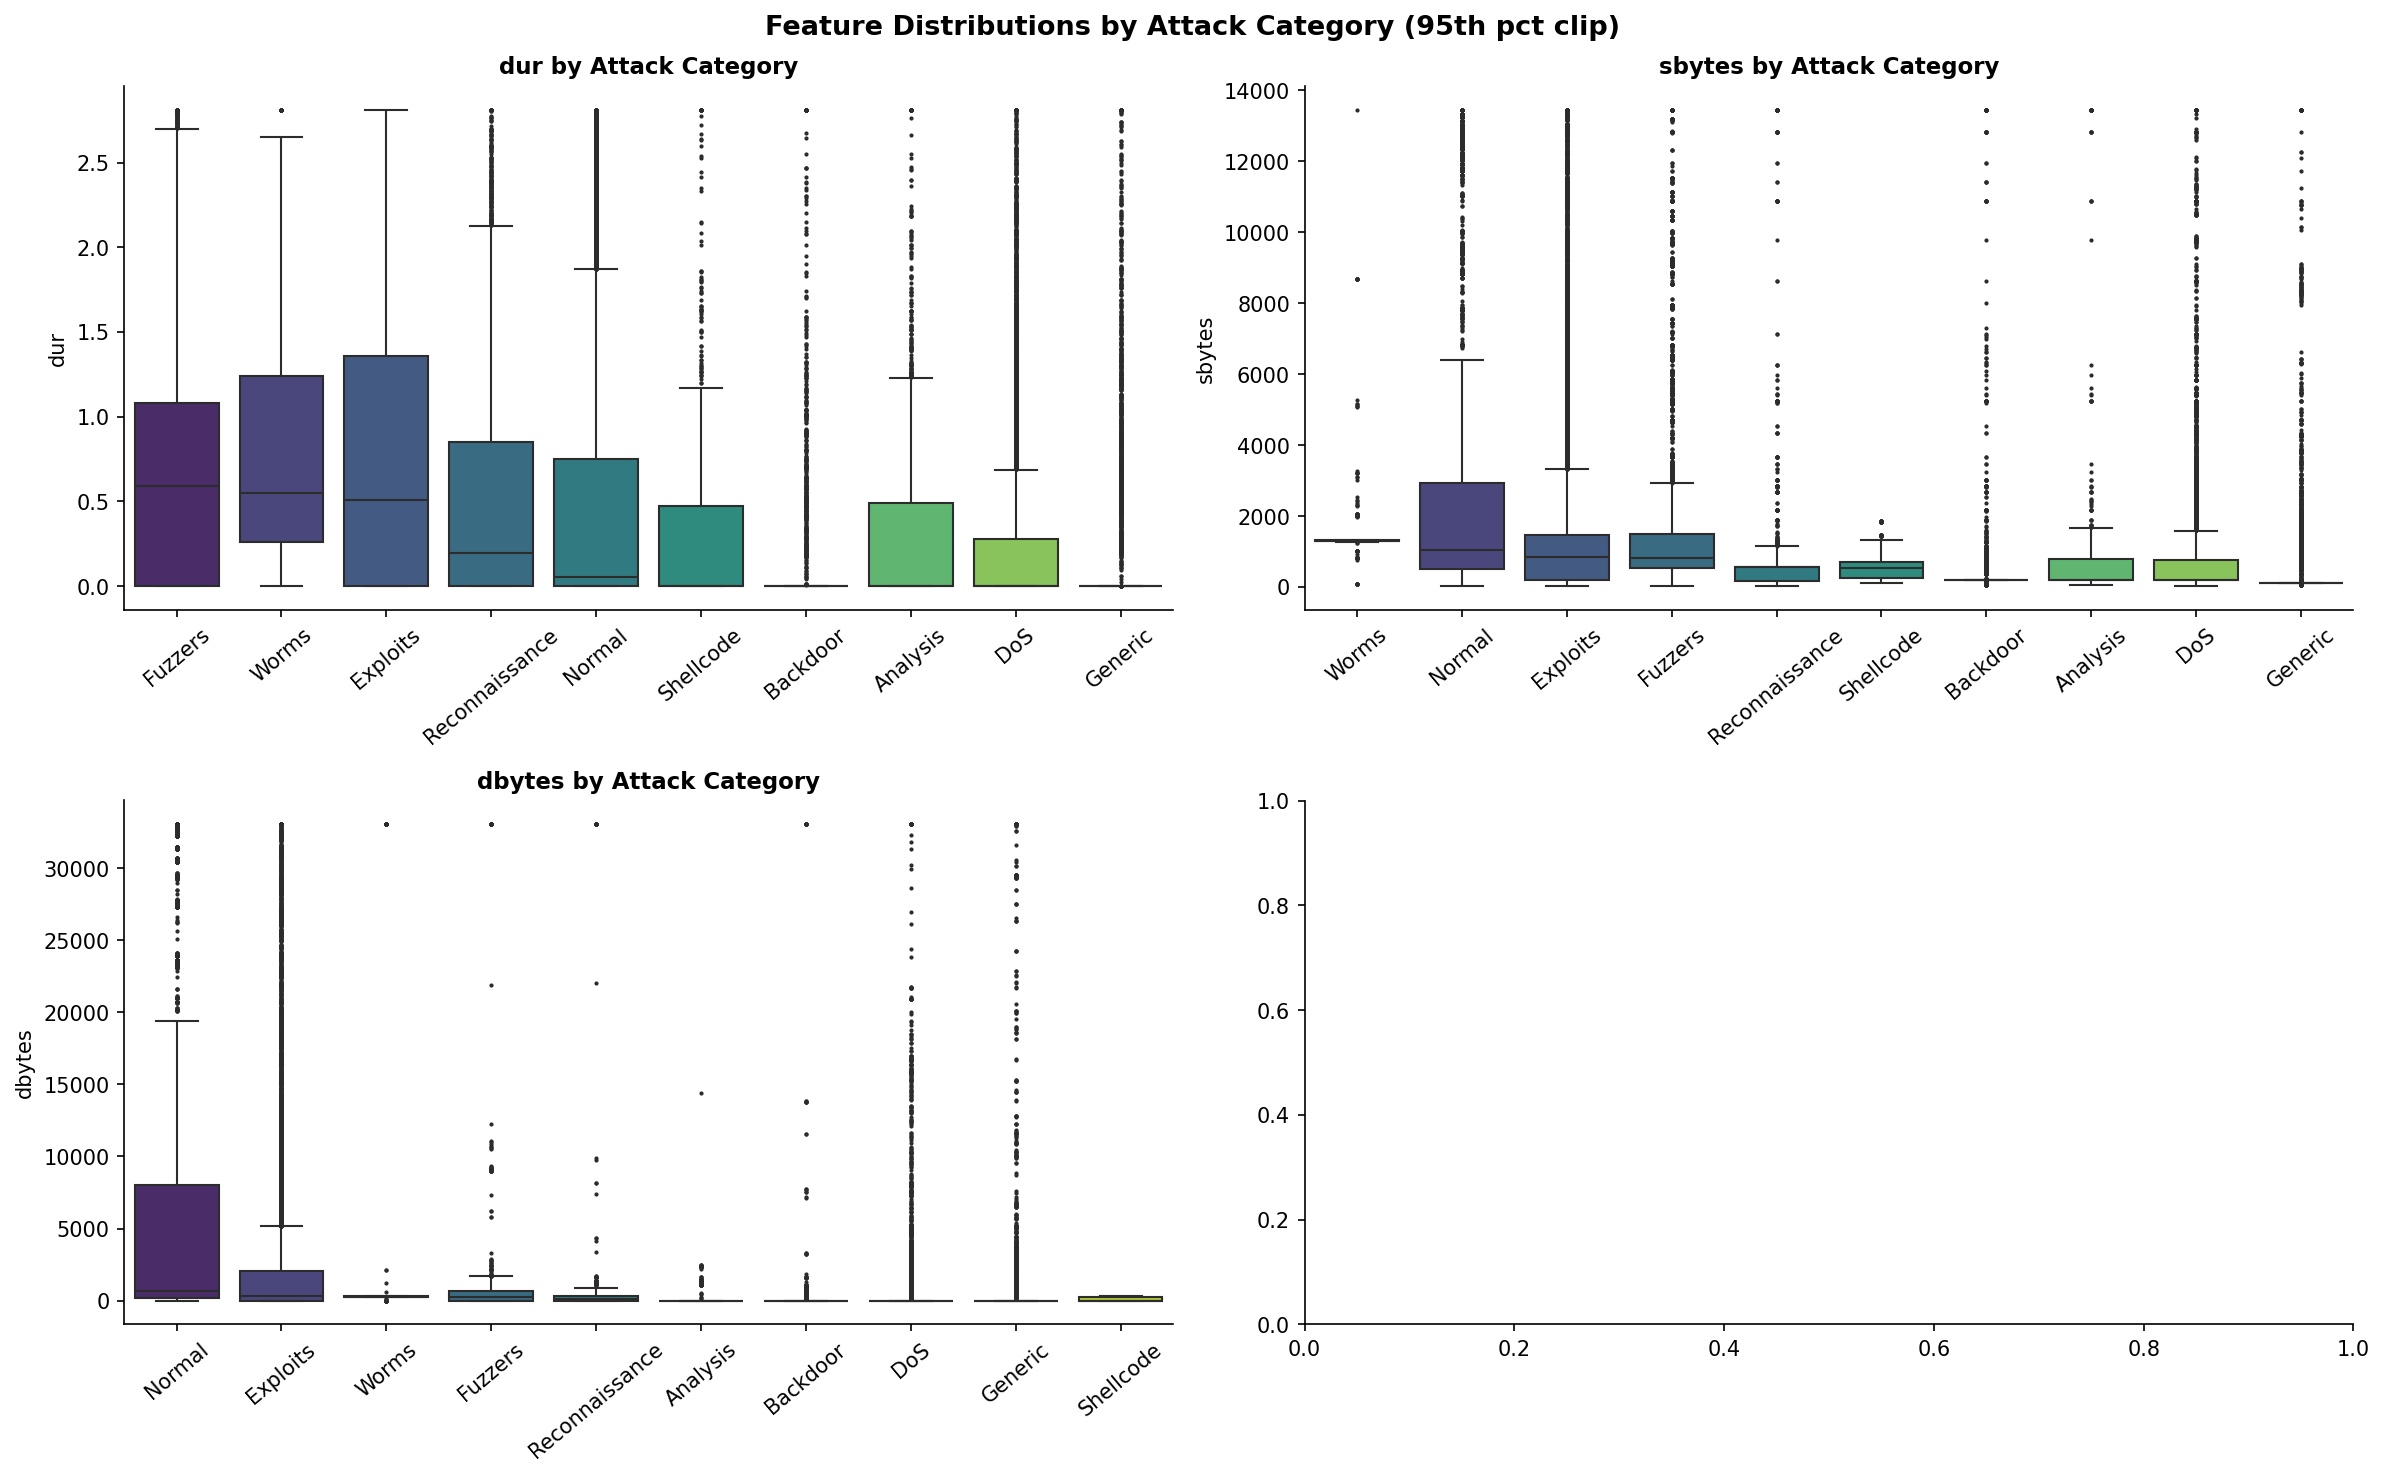

In [19]:
box_features = ['dur', 'sbytes', 'dbytes', 'Sload']
box_features = [f for f in box_features if f in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(box_features):
    sub = df[[feat, 'attack_cat']].copy()
    sub[feat] = sub[feat].clip(upper=sub[feat].quantile(0.95))
    order = sub.groupby('attack_cat')[feat].median().sort_values(ascending=False).index
    sns.boxplot(data=sub, x='attack_cat', y=feat, order=order,
                palette='viridis', ax=axes[i], fliersize=1)
    axes[i].set_title(f'{feat} by Attack Category', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=40)

plt.suptitle('Feature Distributions by Attack Category (95th pct clip)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGS}/07_boxplots_by_category.png', bbox_inches='tight')
plt.show()

### 4.8 Pairplot - Top Discriminative Features

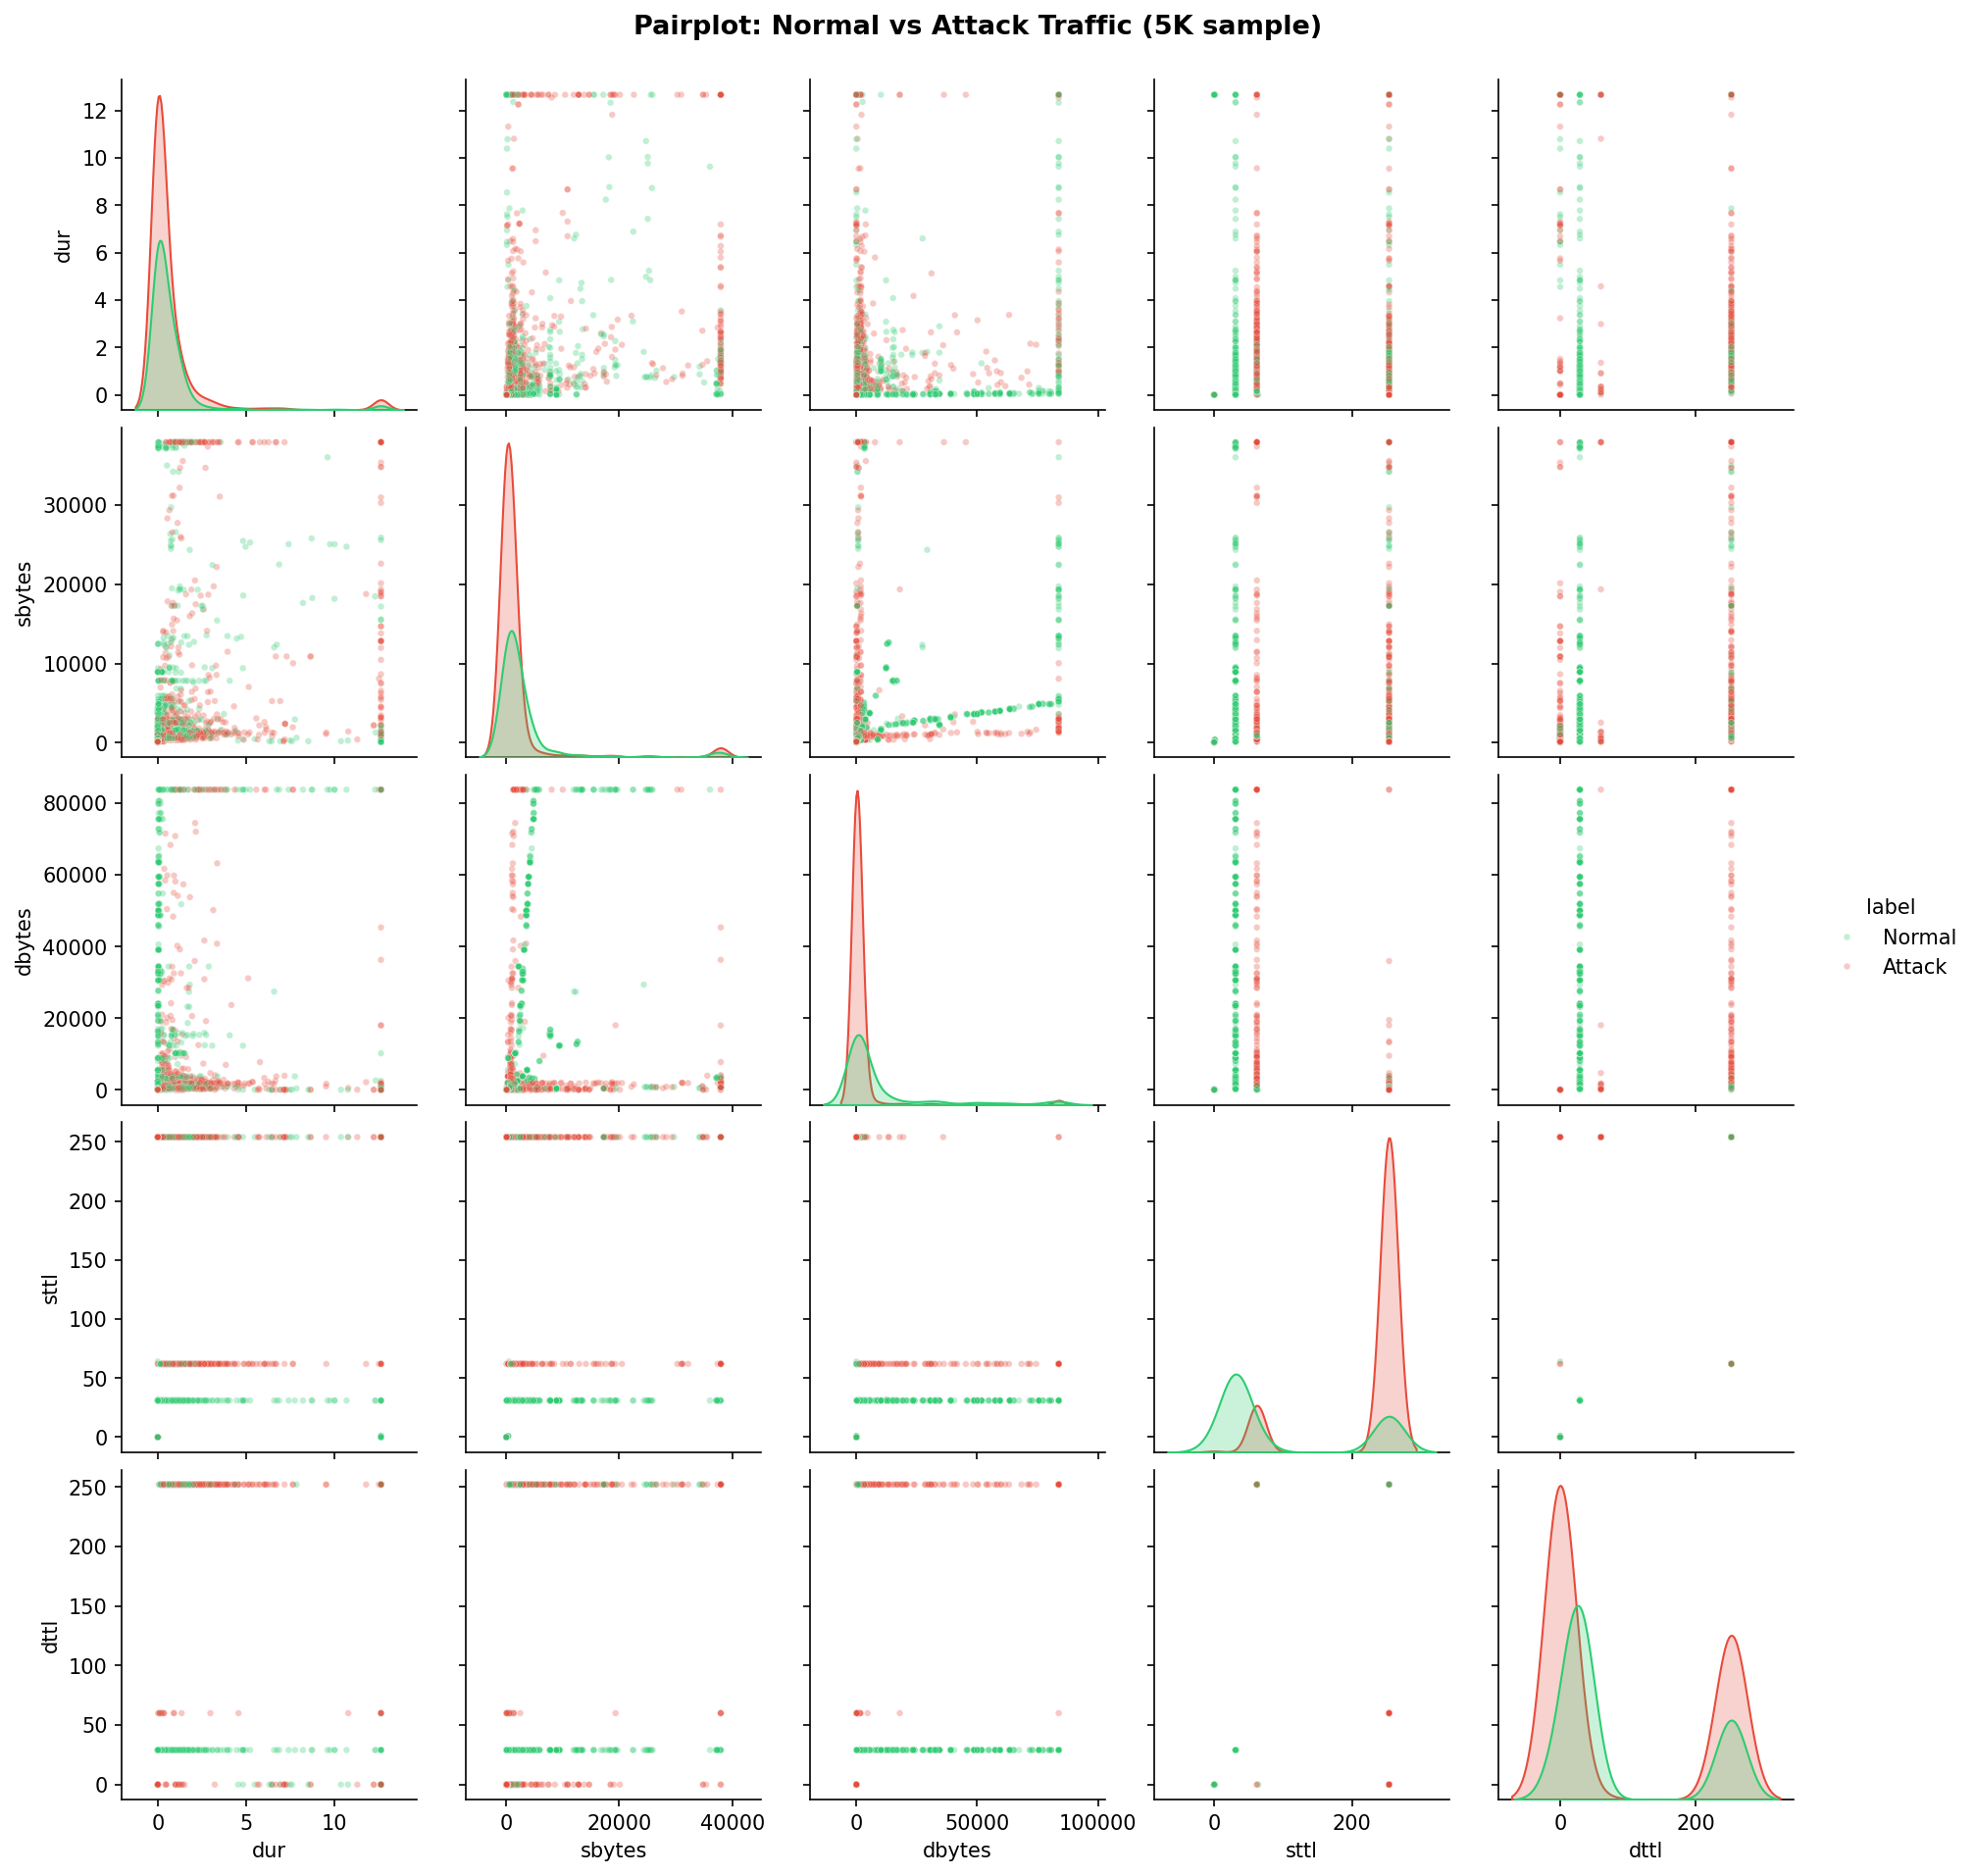

In [20]:
pair_feats = ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'label']
pair_feats = [f for f in pair_feats if f in df.columns]

sample = df[pair_feats].sample(n=min(5000, len(df)), random_state=42)
sample['label'] = sample['label'].map({0: 'Normal', 1: 'Attack'})

for col in pair_feats[:-1]:
    sample[col] = sample[col].clip(upper=sample[col].quantile(0.98))

g = sns.pairplot(sample, hue='label', palette={'Normal': '#2ecc71', 'Attack': '#e74c3c'},
                 plot_kws={'alpha': 0.3, 's': 10}, diag_kind='kde')
g.fig.suptitle('Pairplot: Normal vs Attack Traffic (5K sample)', y=1.02, fontsize=13, fontweight='bold')
plt.savefig(f'{FIGS}/08_pairplot.png', bbox_inches='tight')
plt.show()

## 5. Feature Engineering

In [21]:
if 'sbytes' in df.columns and 'dbytes' in df.columns:
    total = df['sbytes'] + df['dbytes'] + 1e-9
    df['byte_ratio']     = df['sbytes'] / total
    df['total_bytes']    = df['sbytes'] + df['dbytes']

if 'Spkts' in df.columns and 'Dpkts' in df.columns:
    df['total_pkts']     = df['Spkts'] + df['Dpkts']
    total_pkts = df['total_pkts'] + 1e-9
    df['pkt_ratio']      = df['Spkts'] / total_pkts

if 'dur' in df.columns and 'total_bytes' in df.columns:
    df['throughput']     = df['total_bytes'] / (df['dur'] + 1e-9)

if 'Sjit' in df.columns and 'Djit' in df.columns:
    df['jit_diff']       = np.abs(df['Sjit'] - df['Djit'])

print('Engineered features added.')
print(f'New shape: {df.shape}')

Engineered features added.
New shape: (257673, 46)


## 6. Categorical Encoding

In [22]:
le_proto   = LabelEncoder()
le_service = LabelEncoder()
le_state   = LabelEncoder()

df['proto_enc']   = le_proto.fit_transform(df['proto'].astype(str))
df['service_enc'] = le_service.fit_transform(df['service'].astype(str))
df['state_enc']   = le_state.fit_transform(df['state'].astype(str))

print('Encoding done.')
print(f'proto   unique: {df["proto"].nunique()}')
print(f'service unique: {df["service"].nunique()}')
print(f'state   unique: {df["state"].nunique()}')

Encoding done.
proto   unique: 133
service unique: 13
state   unique: 11


## 7. Feature Selection via Mutual Information

In [23]:
drop_for_features = ['label', 'attack_cat', 'proto', 'service', 'state']
feature_cols = [c for c in df.columns if c not in drop_for_features]

X_mi = df[feature_cols].select_dtypes(include=[np.number]).fillna(0)
y_mi = df['label'].astype(int)

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({'feature': X_mi.columns, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False).reset_index(drop=True)

print('Top 20 features by Mutual Information:')
print(mi_df.head(20).to_string(index=False))

Top 20 features by Mutual Information:
     feature  mi_score
 total_bytes  0.464861
      sbytes  0.457235
  byte_ratio  0.376312
  throughput  0.357567
       sload  0.339984
ct_state_ttl  0.339651
        sttl  0.339358
      dbytes  0.338503
       smean  0.333840
          id  0.325359
        dttl  0.315015
        rate  0.313636
         dur  0.302464
       dmean  0.282352
      dinpkt  0.271062
       dload  0.252015
       dpkts  0.241822
      sinpkt  0.225094
      tcprtt  0.218139
      synack  0.216834


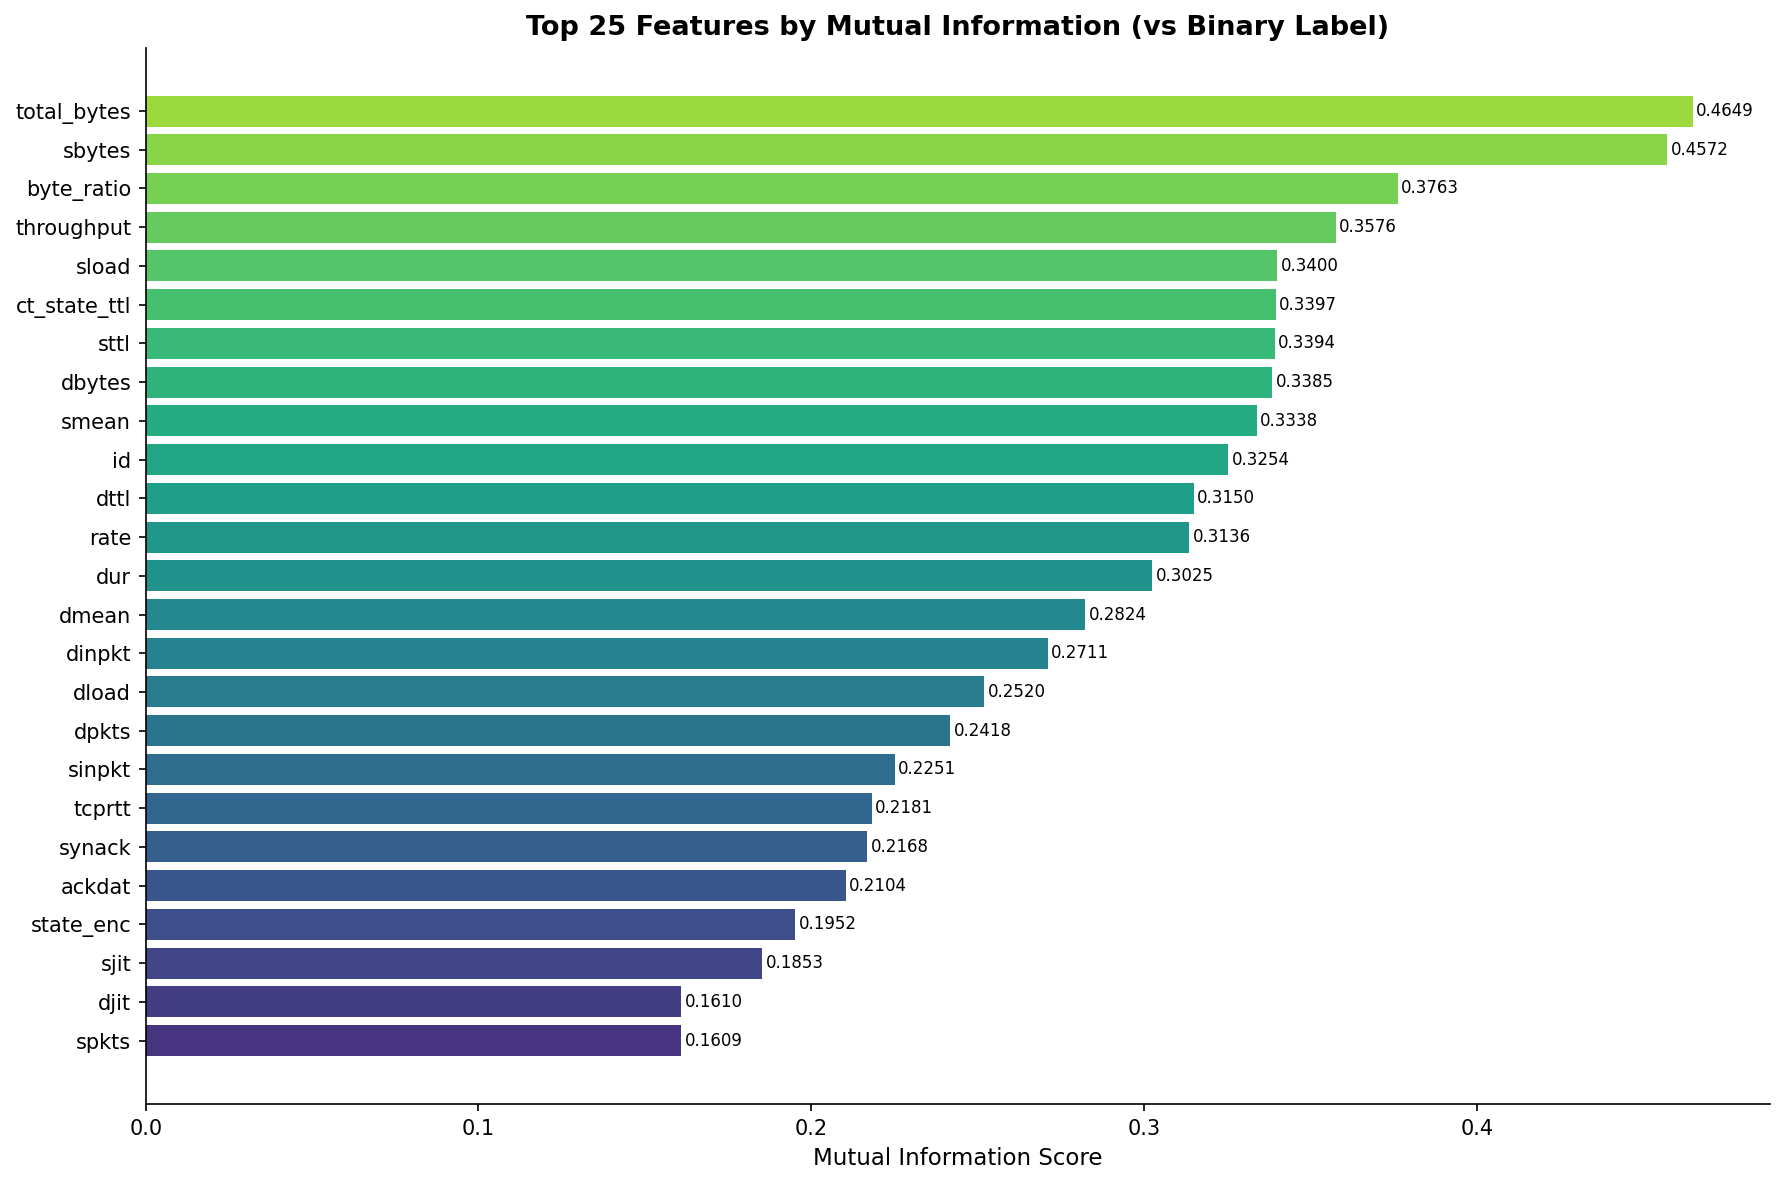

In [24]:
fig, ax = plt.subplots(figsize=(12, 8))
top_mi = mi_df.head(25)
colors = plt.cm.viridis(np.linspace(0.85, 0.15, len(top_mi)))
bars = ax.barh(top_mi['feature'][::-1], top_mi['mi_score'][::-1], color=colors[::-1])
ax.set_xlabel('Mutual Information Score', fontsize=11)
ax.set_title('Top 25 Features by Mutual Information (vs Binary Label)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_mi['mi_score'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGS}/09_mutual_information.png', bbox_inches='tight')
plt.show()

In [25]:
TOP_N = 30
selected_features = mi_df.head(TOP_N)['feature'].tolist()
print(f'Selected top {TOP_N} features:')
print(selected_features)

Selected top 30 features:
['total_bytes', 'sbytes', 'byte_ratio', 'throughput', 'sload', 'ct_state_ttl', 'sttl', 'dbytes', 'smean', 'id', 'dttl', 'rate', 'dur', 'dmean', 'dinpkt', 'dload', 'dpkts', 'sinpkt', 'tcprtt', 'synack', 'ackdat', 'state_enc', 'sjit', 'djit', 'spkts', 'ct_dst_sport_ltm', 'proto_enc', 'dloss', 'sloss', 'ct_srv_dst']


## 8. Prepare Final Feature Matrix

In [26]:
le_cat = LabelEncoder()
df['attack_cat_enc'] = le_cat.fit_transform(df['attack_cat'])

print('Attack category encoding:')
for i, cls in enumerate(le_cat.classes_):
    print(f'  {i} -> {cls}')

Attack category encoding:
  0 -> Analysis
  1 -> Backdoor
  2 -> DoS
  3 -> Exploits
  4 -> Fuzzers
  5 -> Generic
  6 -> Normal
  7 -> Reconnaissance
  8 -> Shellcode
  9 -> Worms


In [27]:
X = df[selected_features].copy()
y_binary = df['label'].astype(int)
y_multi  = df['attack_cat_enc'].astype(int)

print(f'Feature matrix X : {X.shape}')
print(f'Binary labels    : {y_binary.shape}  |  Classes: {y_binary.nunique()}')
print(f'Multi labels     : {y_multi.shape}   |  Classes: {y_multi.nunique()}')

Feature matrix X : (257673, 30)
Binary labels    : (257673,)  |  Classes: 2
Multi labels     : (257673,)   |  Classes: 10


## 9. Normalization (Min-Max Scaling)

In [28]:
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Min-Max scaling applied.')
print(f'Feature range after scaling: [{X_scaled.min().min():.2f}, {X_scaled.max().max():.2f}]')

Min-Max scaling applied.
Feature range after scaling: [0.00, 1.00]


## 10. Train / Test Split
We use a stratified 80/20 split to preserve class proportions.

In [29]:
X_train, X_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
    X_scaled, y_binary, y_multi,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'\nTrain label distribution:')
print(y_bin_train.value_counts())
print(f'\nTest label distribution:')
print(y_bin_test.value_counts())

Train size : (206138, 30)
Test size  : (51535, 30)

Train label distribution:
label
1    131738
0     74400
Name: count, dtype: int64

Test label distribution:
label
1    32935
0    18600
Name: count, dtype: int64


## 11. Handle Class Imbalance with SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) is applied only on training data  
to avoid data leakage into the test set.

In [30]:
print(f'Before SMOTE - Train class distribution:')
print(y_bin_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_bin_train_bal = smote.fit_resample(X_train, y_bin_train)

print(f'\nAfter SMOTE - Train class distribution:')
print(pd.Series(y_bin_train_bal).value_counts())
print(f'\nNew train shape: {X_train_bal.shape}')

Before SMOTE - Train class distribution:
label
1    131738
0     74400
Name: count, dtype: int64

After SMOTE - Train class distribution:
label
1    131738
0    131738
Name: count, dtype: int64

New train shape: (263476, 30)


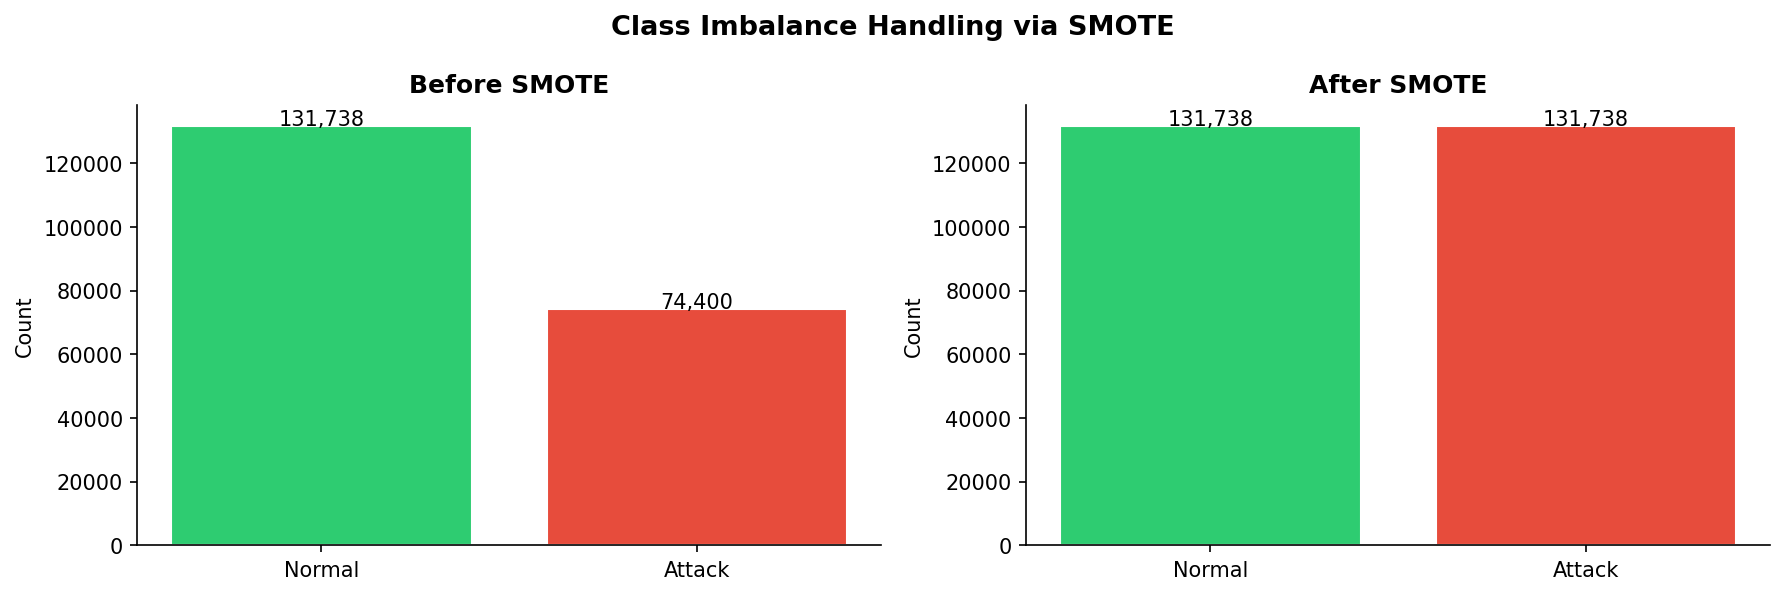

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = y_bin_train.value_counts()
after  = pd.Series(y_bin_train_bal).value_counts()

axes[0].bar(['Normal', 'Attack'], before.values, color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

axes[1].bar(['Normal', 'Attack'], after.values, color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Class Imbalance Handling via SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGS}/10_smote_comparison.png', bbox_inches='tight')
plt.show()

## 12. Save Processed Data to Drive

In [32]:
import joblib

X_train_bal_df = pd.DataFrame(X_train_bal, columns=X_train.columns)
X_test_df      = pd.DataFrame(X_test,      columns=X_train.columns)

X_train_bal_df['label']      = y_bin_train_bal
X_train_bal_df['label_multi'] = np.nan

X_test_df['label']       = y_bin_test.values
X_test_df['label_multi'] = y_multi_test.values

X_train_bal_df.to_csv(f'{PROC}/train_processed.csv', index=False)
X_test_df.to_csv(f'{PROC}/test_processed.csv', index=False)

joblib.dump(scaler,  f'{PROC}/scaler.pkl')
joblib.dump(le_cat,  f'{PROC}/label_encoder_cat.pkl')
joblib.dump(le_proto, f'{PROC}/label_encoder_proto.pkl')

pd.Series(selected_features).to_csv(f'{PROC}/selected_features.csv', index=False, header=False)

print('Saved:')
print(f'  train_processed.csv   : {X_train_bal_df.shape}')
print(f'  test_processed.csv    : {X_test_df.shape}')
print(f'  scaler.pkl')
print(f'  label_encoder_cat.pkl')
print(f'  selected_features.csv')

Saved:
  train_processed.csv   : (263476, 32)
  test_processed.csv    : (51535, 32)
  scaler.pkl
  label_encoder_cat.pkl
  selected_features.csv


## 13. EDA Summary Report

In [33]:
print('=' * 55)
print('           EDA & PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Total records loaded       : {len(df):,}')
print(f'Features after selection   : {len(selected_features)}')
print(f'Normal records             : {(y_binary == 0).sum():,}')
print(f'Attack records             : {(y_binary == 1).sum():,}')
print(f'Attack categories          : {df["attack_cat"].nunique()}')
print(f'Train size (after SMOTE)   : {X_train_bal.shape[0]:,}')
print(f'Test size                  : {X_test.shape[0]:,}')
print(f'Scaler applied             : MinMaxScaler')
print(f'Imbalance handling         : SMOTE (k=5)')
print(f'Figures saved to           : {FIGS}')
print(f'Processed data saved to    : {PROC}')
print('=' * 55)
print('Ready for Notebook 3: Modeling')

           EDA & PREPROCESSING SUMMARY
Total records loaded       : 257,673
Features after selection   : 30
Normal records             : 93,000
Attack records             : 164,673
Attack categories          : 10
Train size (after SMOTE)   : 263,476
Test size                  : 51,535
Scaler applied             : MinMaxScaler
Imbalance handling         : SMOTE (k=5)
Figures saved to           : /content/drive/MyDrive/CSC5800_NIDS_Project/figures
Processed data saved to    : /content/drive/MyDrive/CSC5800_NIDS_Project/data/processed
Ready for Notebook 3: Modeling
